,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


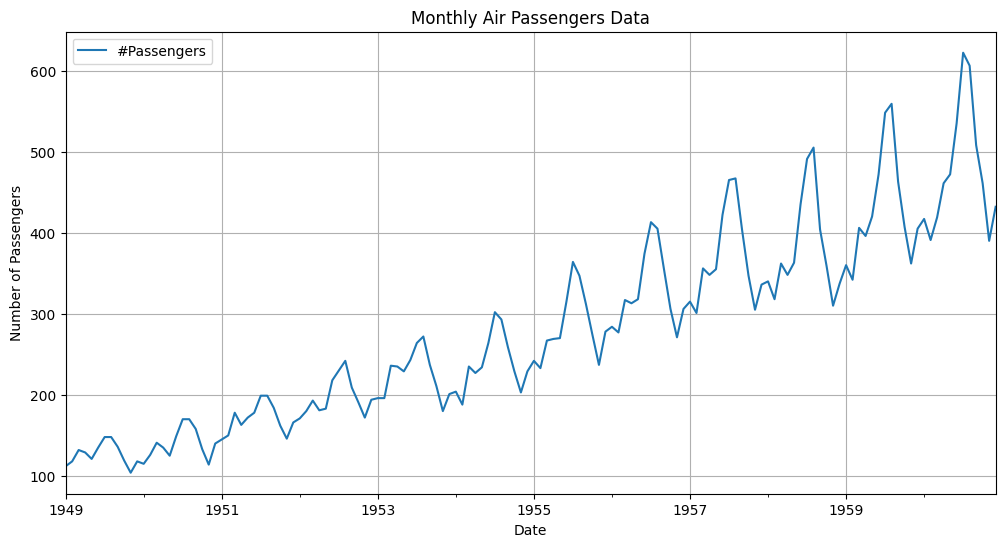

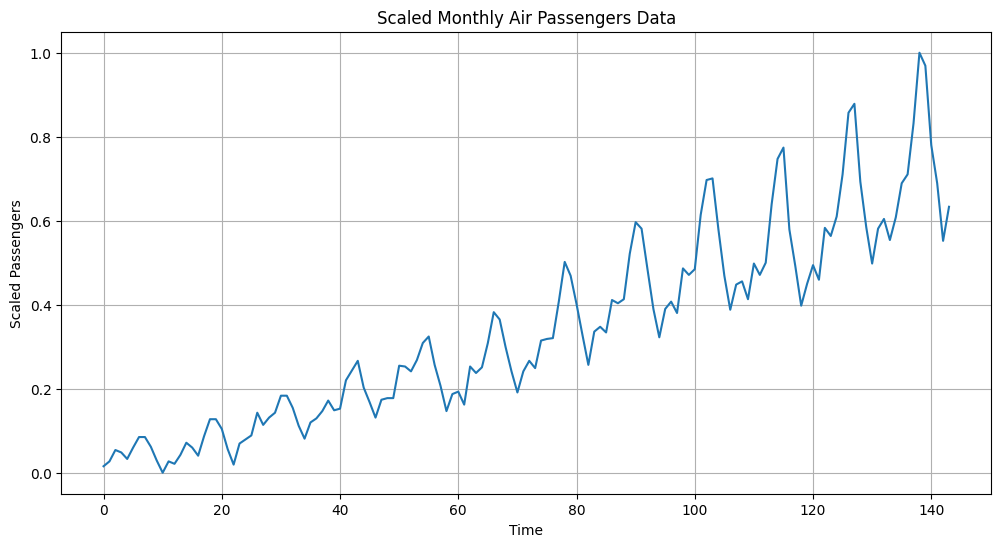

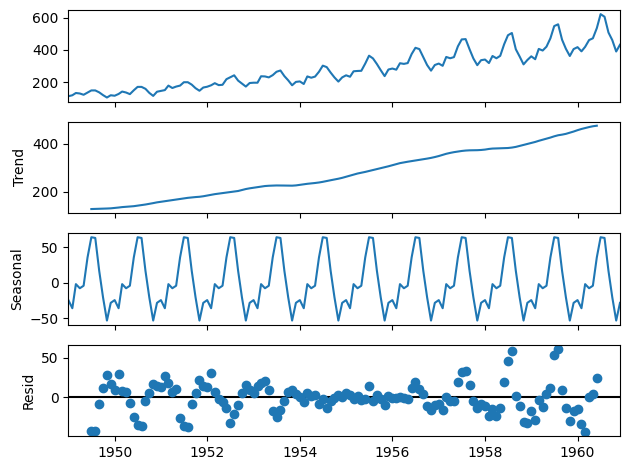

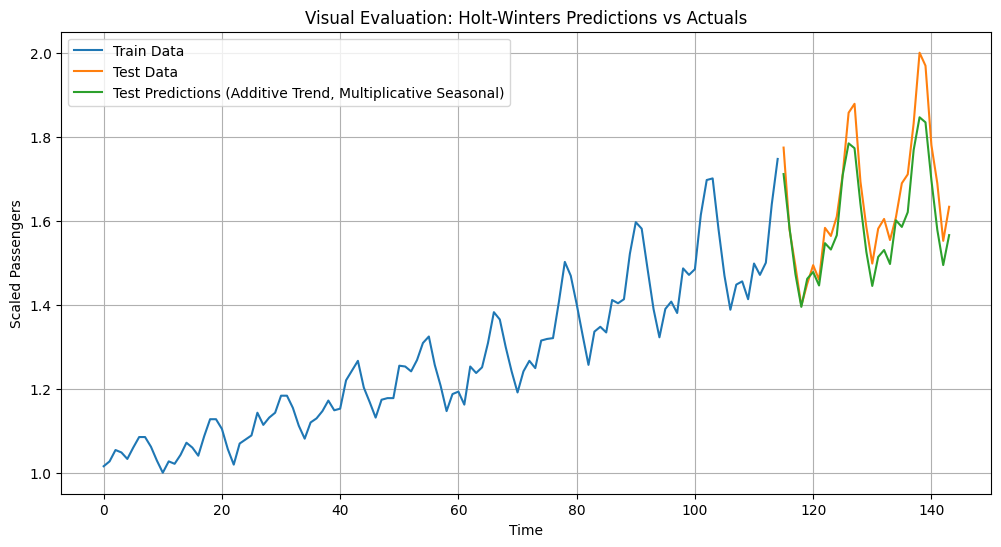

Root Mean Squared Error (RMSE) on test data: 0.0695
Mean Absolute Error (MAE) on test data: 0.0573
Scaled data variance: 0.2316, Scaled data mean: 1.3403


<Figure size 1200x600 with 0 Axes>

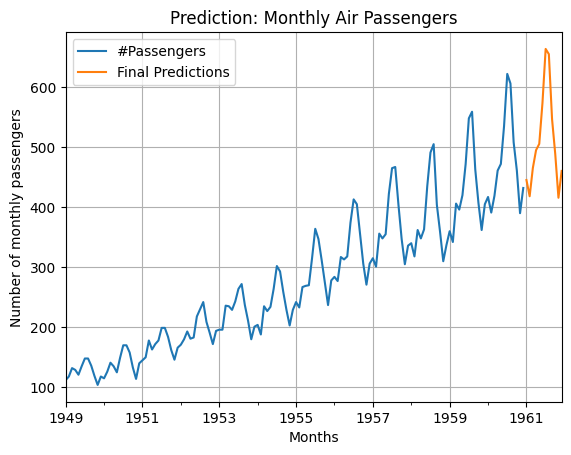

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

data = pd.read_csv('/content/drive/MyDrive/COLAB PROJECTS/Time Series/AirPassengers.csv', parse_dates=['Month'], index_col='Month')
display(data.head())

data_monthly = data.resample('MS').sum()
display(data_monthly.head())

data_monthly.plot(figsize=(12, 6))
plt.title('Monthly Air Passengers Data')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.show()

scaler = MinMaxScaler()
scaled_data = pd.Series(scaler.fit_transform(data_monthly.values.reshape(-1, 1)).flatten())

scaled_data.plot(figsize=(12, 6))
plt.title('Scaled Monthly Air Passengers Data')
plt.xlabel('Time')
plt.ylabel('Scaled Passengers')
plt.grid(True)
plt.show()

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(data_monthly, model="additive", period=12)

decomposition.plot()
plt.show()

scaled_data = scaled_data + 1

train_data = scaled_data[:int(len(scaled_data) * 0.8)]
test_data = scaled_data[int(len(scaled_data) * 0.8):]

model_add = ExponentialSmoothing(train_data, trend='add', seasonal='mul', seasonal_periods=12).fit()

test_predictions_add = model_add.forecast(steps=len(test_data))

plt.figure(figsize=(12, 6))
ax = train_data.plot(label='Train Data')
test_data.plot(ax=ax, label='Test Data')
test_predictions_add.plot(ax=ax, label='Test Predictions (Additive Trend, Multiplicative Seasonal)')
ax.legend()
ax.set_title('Visual Evaluation: Holt-Winters Predictions vs Actuals')
plt.xlabel('Time')
plt.ylabel('Scaled Passengers')
plt.grid(True)
plt.show()

rmse = np.sqrt(mean_squared_error(test_data, test_predictions_add))
mae = mean_absolute_error(test_data, test_predictions_add)
print(f"Root Mean Squared Error (RMSE) on test data: {rmse:.4f}")
print(f"Mean Absolute Error (MAE) on test data: {mae:.4f}")

print(f"Scaled data variance: {np.sqrt(scaled_data.var()):.4f}, Scaled data mean: {scaled_data.mean():.4f}")

final_model = ExponentialSmoothing(data_monthly, trend='add', seasonal='mul', seasonal_periods=12).fit()

final_predictions = final_model.forecast(steps=12)

plt.figure(figsize=(12, 6))
ax = data_monthly.plot(label='Historical Data')
final_predictions.plot(ax=ax, label='Final Predictions')
ax.legend()
ax.set_xlabel('Months')
ax.set_ylabel('Number of monthly passengers')
ax.set_title('Prediction: Monthly Air Passengers')
plt.grid(True)
plt.show()